In [114]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer



train_data = pd.read_csv("csv/train.csv",  encoding='latin-1')
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


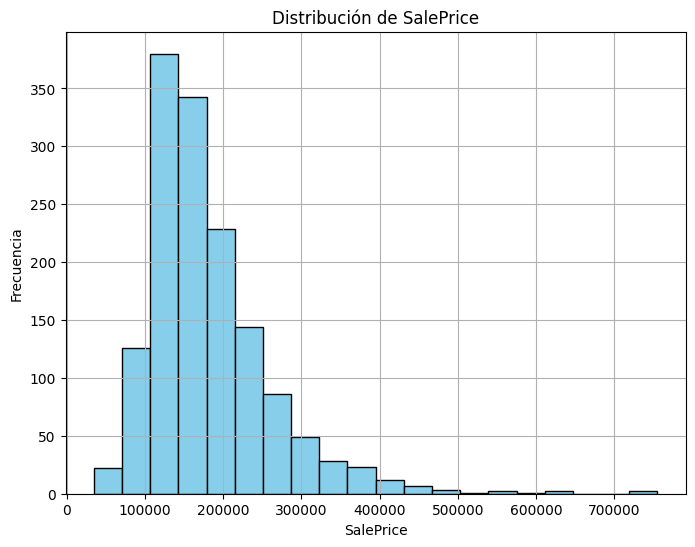

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [3]:
plt.figure(figsize=(8, 6))
plt.hist(train_data['SalePrice'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()
print(train_data['SalePrice'].describe())

In [4]:
train_data.pop("LotFrontage")
train_data.pop("Id")
print(train_data.isnull().sum())

MSSubClass          0
MSZoning            0
LotArea             0
Street              0
Alley            1369
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 79, dtype: int64


In [5]:
print(train_data.dtypes)

MSSubClass        int64
MSZoning         object
LotArea           int64
Street           object
Alley            object
                  ...  
MoSold            int64
YrSold            int64
SaleType         object
SaleCondition    object
SalePrice         int64
Length: 79, dtype: object


In [6]:
y = train_data.pop("SalePrice")
X = train_data

In [7]:
y_mean= y.mean()
print(y, '\n')
print(X)
print(X.columns)

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64 

      MSSubClass MSZoning  LotArea Street Alley LotShape LandContour  \
0             60       RL     8450   Pave   NaN      Reg         Lvl   
1             20       RL     9600   Pave   NaN      Reg         Lvl   
2             60       RL    11250   Pave   NaN      IR1         Lvl   
3             70       RL     9550   Pave   NaN      IR1         Lvl   
4             60       RL    14260   Pave   NaN      IR1         Lvl   
...          ...      ...      ...    ...   ...      ...         ...   
1455          60       RL     7917   Pave   NaN      Reg         Lvl   
1456          20       RL    13175   Pave   NaN      Reg         Lvl   
1457          70       RL     9042   Pave   NaN      Reg         Lvl   
1458          20       RL     9717   Pave   NaN      Reg         Lvl 

In [8]:
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.3,train_size=0.7,random_state=0)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1021, 78)
(438, 78)
(1021,)
(438,)


# Modelo

In [9]:
numerical_columns_selector = selector(dtype_exclude=object)
categorical_columns_selector = selector(dtype_include=object)

numerical_columns = numerical_columns_selector(train_data)
categorical_columns = categorical_columns_selector(train_data)
print('Categoricas:\n', categorical_columns)
print('Numericas:\n',numerical_columns)

Categoricas:
 ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Numericas:
 ['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchS

In [10]:
categorical_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Imputar con el valor más frecuente
    ('encoder', OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

numerical_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Imputar con la mediana
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('one-hot-encoder', categorical_preprocessor, categorical_columns),
    ('standard-scaler', numerical_preprocessor, numerical_columns)
])

    

In [11]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GaussianNB())
])
#params = [{
#    "regressor__max_depth": np.arange(2, 10, 1)
#}]
pipeline.get_params()

{'memory': None,
 'steps': [('preprocessor',
   ColumnTransformer(transformers=[('one-hot-encoder',
                                    Pipeline(steps=[('imputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('encoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                                                   sparse_output=False))]),
                                    ['MSZoning', 'Street', 'Alley', 'LotShape',
                                     'LandContour', 'Utilities', 'LotConfig',
                                     'LandSlope', 'Neighborhood', 'Condition1',
                                     'Condition2', 'BldgType', 'HouseStyle',
                                     'Ro...
                                     'OverallCond', 'YearBuilt', 'YearRemodAdd',
                                     'MasVnrArea', 'B

In [12]:
modelo = pipeline.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
rmse = root_mean_squared_error(y_test,y_pred)
rmse

68292.01121473452

## El error es de 68,292 dolares por casa aproximadamente

In [13]:
porcentaje = rmse / y_mean * 100
porcentaje

np.float64(37.74682721868637)

## El porcentaje de error con la media de SalePrice (180,921 dolares) es de 37.75%, lo cual es alto

# Vamos a mejorar el modelo

In [14]:
params =  [{
    "regressor__var_smoothing": np.logspace(0,-9, num=300)
}]
modelo = GridSearchCV(pipeline,param_grid=params,n_jobs=2, cv=5,scoring="neg_root_mean_squared_error")
modelo.fit(X_train,y_train)
modelo.best_params_

c:\Users\thiag\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


{'regressor__var_smoothing': np.float64(0.30781821425650796)}

El mejor valor es 0.3078. Vamos a predecir con el mejor modelo.

In [15]:
print(modelo.best_estimator_)
print('best score:')
print(modelo.best_score_)
y_mejor_pred = modelo.best_estimator_.predict(X_test)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('one-hot-encoder',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['MSZoning', 'Street',
                                                   'Alley', 'LotShape',
                                                   'LandContour', 'Utilities',
                                                   'LotConfig', 'LandSlope',
                                                   'Neighborhood', 'Condition1',
                                       

In [16]:
rmse_tunned = root_mean_squared_error(y_test,y_mejor_pred)
rmse_tunned

48012.1767391894

### El error es de 48,012 dolares por casa aproximadamente

In [17]:
porcentaje = rmse_tunned / y_mean * 100
porcentaje

np.float64(26.53761849345266)

## El porcentaje de error con la media de SalePrice (180,921 dolares) es de 26.54%, lo cual es aceptable

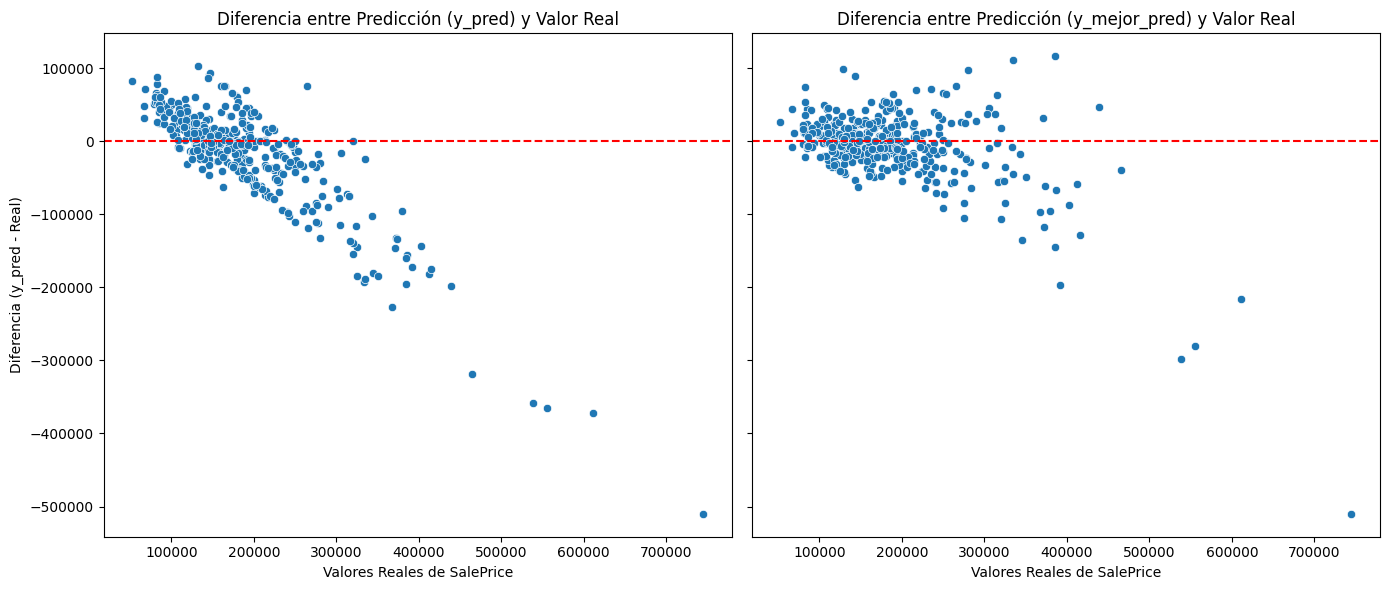

In [18]:
differences_y_pred = y_pred - y_test
differences_y_mejor_pred = y_mejor_pred - y_test

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Gráfico para y_pred
sns.scatterplot(x=y_test, y=differences_y_pred, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')  # Línea horizontal en 0
axes[0].set_xlabel('Valores Reales de SalePrice')
axes[0].set_ylabel('Diferencia (y_pred - Real)')
axes[0].set_title('Diferencia entre Predicción (y_pred) y Valor Real')

# Gráfico para y_mejor_pred
sns.scatterplot(x=y_test, y=differences_y_mejor_pred, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')  # Línea horizontal en 0
axes[1].set_xlabel('Valores Reales de SalePrice')
axes[1].set_ylabel('Diferencia (y_mejor_pred - Real)')
axes[1].set_title('Diferencia entre Predicción (y_mejor_pred) y Valor Real')

# Mostrar los gráficos
plt.tight_layout()
plt.show()

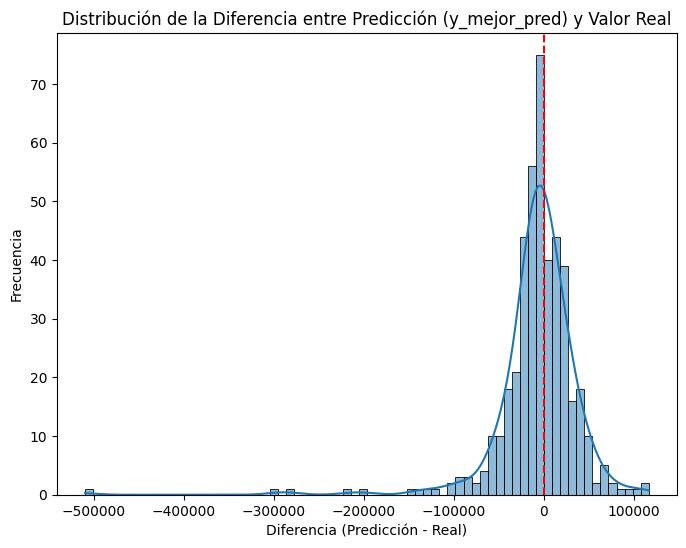

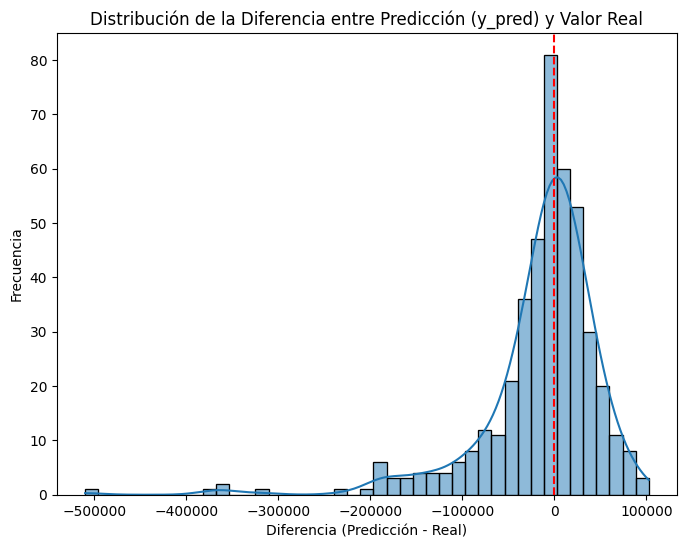

In [19]:
differences = y_mejor_pred - y_test

# Graficar la distribución de las diferencias
plt.figure(figsize=(8, 6))
sns.histplot(differences, kde=True)
plt.axvline(0, color='red', linestyle='--')  # Línea en 0 para ver la tendencia
plt.xlabel('Diferencia (Predicción - Real)')
plt.ylabel('Frecuencia')
plt.title('Distribución de la Diferencia entre Predicción (y_mejor_pred) y Valor Real')
plt.show()

differences = y_pred - y_test

# Graficar la distribución de las diferencias
plt.figure(figsize=(8, 6))
sns.histplot(differences, kde=True)
plt.axvline(0, color='red', linestyle='--')  # Línea en 0 para ver la tendencia
plt.xlabel('Diferencia (Predicción - Real)')
plt.ylabel('Frecuencia')
plt.title('Distribución de la Diferencia entre Predicción (y_pred) y Valor Real')
plt.show()

In [20]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmae = root_mean_squared_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE) "y" normal: {mae}')
print(f'Root Mean Absolute Error (RMAE) "y" normal: {rmae}')

mae = mean_absolute_error(y_test, y_mejor_pred)
rmae = root_mean_squared_error(y_test, y_mejor_pred)
print(f'Mean Absolute Error (MAE) "y" mejorada: {mae}')
print(f'Root Mean Absolute Error (RMAE) "y" mejorada: {rmae}')

Mean Absolute Error (MAE) "y" normal: 41072.21917808219
Root Mean Absolute Error (RMAE) "y" normal: 68292.01121473452
Mean Absolute Error (MAE) "y" mejorada: 27396.61415525114
Root Mean Absolute Error (RMAE) "y" mejorada: 48012.1767391894


El modelo de Naive Bayes Gaussiano aplicado a regresión ha demostrado una mejora clara tras la optimización, con una reducción considerable en las métricas de error. Sin embargo, los valores de RMAE aún indican que existen errores significativos en algunas predicciones, penalizando un 26% a los precios pequeños y un 29% a los precios grandes.

# Modelo con variable PriceCategory


In [101]:
train_data_2 = pd.read_csv("csv/train.csv",  encoding='latin-1')

saleprice_summary = train_data_2["SalePrice"].describe()

# Calcular percentiles para definir los rangos de clasificación
q1 = train_data_2["SalePrice"].quantile(0.33)  # 33% más barato
q2 = train_data_2["SalePrice"].quantile(0.66)  # 66% intermedio
print(q1, q2,  train_data_2["SalePrice"].max())

# Crear la nueva variable categórica basada en los percentiles
train_data_2["PriceCategory"] = pd.cut(train_data_2["SalePrice"], 
                             bins=[train_data_2["SalePrice"].min(), q1, q2, train_data_2["SalePrice"].max()], 
                             labels=[0, 1, 2], #"Económica (0)", "Intermedia(1)", "Cara(2)" 
                             include_lowest=True)

# Mostrar resumen de la variable categórica creada
train_data_2[["PriceCategory", "SalePrice"]]


139000.0 189893.00000000006 755000


,PriceCategory,SalePrice
0,2,208500
1,1,181500
2,2,223500
3,1,140000
4,2,250000
...,...,...
1455,1,175000
1456,2,210000
1457,2,266500
1458,1,142125


In [102]:
train_data_2.pop("LotFrontage")
train_data_2.pop("Id")
print(train_data_2.isnull().sum())

MSSubClass          0
MSZoning            0
LotArea             0
Street              0
Alley            1369
                 ... 
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
PriceCategory       0
Length: 80, dtype: int64


In [103]:
category = train_data_2.pop("PriceCategory") 


In [104]:
categorical_cols = train_data_2.select_dtypes(include=['object', 'category']).columns

# Aplicar OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe_transformed = ohe.fit_transform(train_data_2[categorical_cols])
ohe_df = pd.DataFrame(ohe_transformed, columns=ohe.get_feature_names_out(categorical_cols))

# Reemplazar columnas originales y concatenar con el resto del dataset
train_data_2 = train_data_2.drop(columns=categorical_cols).reset_index(drop=True)
train_data_2 = pd.concat([train_data_2, ohe_df], axis=1)

train_data_2.corr()

,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
MSSubClass,1.000000,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,-0.065649,-0.140759,...,-0.001244,0.014005,-0.045156,-0.014555,0.026359,0.016241,0.030002,0.000983,0.024359,-0.051068
LotArea,-0.139781,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,-0.002618,...,0.001076,-0.015040,0.020039,-0.005722,-0.002292,-0.013208,0.008966,-0.010781,0.005711,0.022635
OverallQual,0.032628,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,0.308159,...,0.004269,-0.021172,0.327412,-0.057962,-0.225013,-0.041677,-0.044950,-0.025515,-0.143282,0.323295
OverallCond,-0.059316,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,-0.136841,...,0.001299,-0.019779,-0.156175,-0.050663,0.163684,-0.038888,-0.033444,-0.023873,0.161642,-0.151659
YearBuilt,0.027850,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,-0.049107,0.149040,...,0.002975,-0.023431,0.346954,0.012122,-0.238463,-0.045601,-0.010104,-0.035785,-0.158427,0.343895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SaleCondition_AdjLand,0.016241,-0.013208,-0.041677,-0.038888,-0.045601,-0.040294,-0.011959,-0.014874,-0.015130,-0.034618,...,-0.003073,-0.003073,-0.015827,-0.002378,0.020457,1.000000,-0.004772,-0.006177,-0.112080,-0.016038
SaleCondition_Alloca,0.030002,0.008966,-0.044950,-0.033444,-0.010104,-0.020727,-0.010116,0.021369,-0.026277,-0.059130,...,-0.005337,-0.005337,-0.027489,-0.004131,0.035530,-0.004772,1.000000,-0.010729,-0.194663,-0.027856
SaleCondition_Family,0.000983,-0.010781,-0.025515,-0.023873,-0.035785,-0.048056,-0.009915,0.000765,-0.007929,0.021534,...,-0.006909,-0.006909,-0.035587,-0.005348,0.028599,-0.006177,-0.010729,1.000000,-0.252006,-0.036062
SaleCondition_Normal,0.024359,0.005711,-0.143282,0.161642,-0.158427,-0.120577,-0.084801,-0.019560,0.041207,-0.153930,...,-0.003139,0.027414,-0.645698,-0.097031,0.634322,-0.112080,-0.194663,-0.252006,1.000000,-0.654323


In [105]:
y = category
X = train_data_2
random.seed(1234)

In [106]:
print(y, '\n')
print(X)
print(X.columns)
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.3,train_size=0.7)

0       2
1       1
2       2
3       1
4       2
       ..
1455    1
1456    2
1457    2
1458    1
1459    1
Name: PriceCategory, Length: 1460, dtype: category
Categories (3, int64): [0 < 1 < 2] 

      MSSubClass  LotArea  OverallQual  OverallCond  YearBuilt  YearRemodAdd  \
0             60     8450            7            5       2003          2003   
1             20     9600            6            8       1976          1976   
2             60    11250            7            5       2001          2002   
3             70     9550            7            5       1915          1970   
4             60    14260            8            5       2000          2000   
...          ...      ...          ...          ...        ...           ...   
1455          60     7917            6            5       1999          2000   
1456          20    13175            6            6       1978          1988   
1457          70     9042            7            9       1941          2006   
14

70% de entrenamiento y 30% prueba

In [107]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1021 entries, 892 to 429
Columns: 260 entries, MSSubClass to SaleCondition_Partial
dtypes: float64(226), int64(34)
memory usage: 2.0 MB


In [108]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438 entries, 321 to 1002
Columns: 260 entries, MSSubClass to SaleCondition_Partial
dtypes: float64(226), int64(34)
memory usage: 893.1 KB


## Modelo

In [113]:
gaussian = GaussianNB() # distribución gaussiana. ¿qué significa y qué implica? 

X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]
X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]  

# train
gaussian.fit(X_train,y_train)

# prediction
y_pred = gaussian.predict(X_test)

# eval_model
cm = confusion_matrix(y_test,y_pred)

print('Confusion matrix for Naive Bayes\n',cm)


Confusion matrix for Naive Bayes
 [[116   3   2]
 [ 60  72  11]
 [  2  14 131]]


- Clase 0 (fila 1): Se predijo correctamente 116 veces y 5 errores.
- Clase 1 (fila 2): Se predijo correctamente 72 veces, y 71 errores.
- Clase 2 (fila 3): Se predijo correctamente 131 veces y 16 errores.

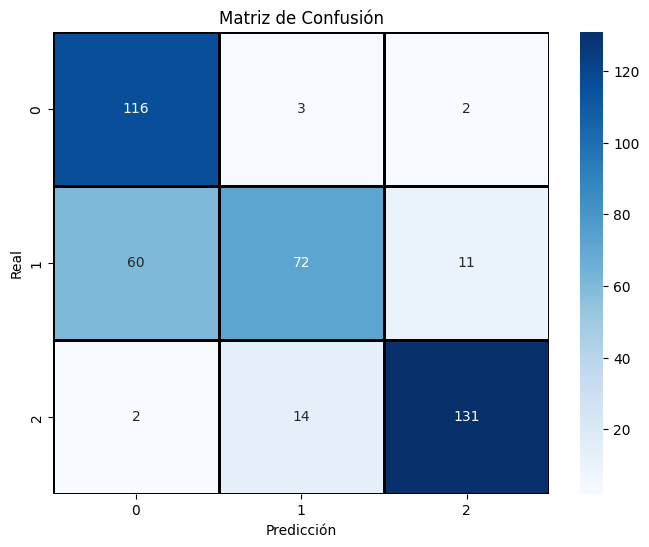

Accuracy:  0.7761557177615572
precision: 0.7761557177615572
recall: 0.7761557177615572
f1:  0.7761557177615572


In [ ]:
accuracy=accuracy_score(y_test,y_pred)
precision =precision_score(y_test, y_pred,average='micro')
recall =  recall_score(y_test, y_pred,average='micro')
f1 = f1_score(y_test,y_pred,average='micro')

# Graficar el heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black')

# Etiquetas de los ejes
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')

# Mostrar el gráfico
plt.show()

print('Accuracy: ',accuracy)
print("precision:", precision)
print("recall:", recall)
print("f1: ", f1)